# Final Transformer -- Configuration, Training, Validation, Regularization, Hyperparameters

In [1]:
from __future__ import annotations

import copy
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

sns.set_theme(style="whitegrid", palette="deep")

THIS_DIR = os.getcwd()
REPO_ROOT = os.path.normpath(os.path.join(THIS_DIR, ".."))
for p in (REPO_ROOT, THIS_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)

from utils import manifest_utils as mu
from Transformer import N_CLASSES, TwoBranchTransformer

FIGURES_DIR = os.path.join(THIS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

RANDOM_SEED = 14
STRIDE = 8
DEVICE = torch.device("cpu")
MAX_EPOCHS = 30
PATIENCE = 5
BATCH_SIZE = 64

torch.manual_seed(RANDOM_SEED)

## 0. Data loading

In [2]:
def load_sequences() -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    manifest = mu.load_manifest()

    n = len(manifest)
    X1 = np.zeros((n, 880, 6), dtype=np.float32)
    X2 = np.zeros((n, 880, 6), dtype=np.float32)
    len1 = np.zeros(n, dtype=np.int64)
    len2 = np.zeros(n, dtype=np.int64)
    y = np.zeros(n, dtype=np.int64)

    row = 0
    for mid, group in manifest.groupby("movement_id"):
        arr1 = mu.load_movement(int(mid), 1)
        arr2 = mu.load_movement(int(mid), 2)
        for r in group.itertuples():
            X1[row] = arr1[r.sample_index]
            X2[row] = arr2[r.sample_index]
            len1[row] = int(r.valid_length_sensor1)
            len2[row] = int(r.valid_length_sensor2)
            y[row] = int(mid)
            row += 1

    return X1, len1, X2, len2, y


def downsample(X: np.ndarray, lengths: np.ndarray, stride: int) -> tuple[np.ndarray, np.ndarray]:
    X_ds = np.ascontiguousarray(X[:, ::stride, :])
    new_len = X_ds.shape[1]
    lengths_ds = np.clip(np.ceil(lengths / stride).astype(np.int64), 1, new_len)
    return X_ds, lengths_ds


class SequenceDataset(Dataset):
    def __init__(self, X1: np.ndarray, len1: np.ndarray, X2: np.ndarray, len2: np.ndarray, y: np.ndarray):
        self.X1 = torch.from_numpy(X1)
        self.len1 = torch.from_numpy(len1)
        self.X2 = torch.from_numpy(X2)
        self.len2 = torch.from_numpy(len2)
        self.y = torch.from_numpy(y)

    def __len__(self) -> int:
        return self.y.shape[0]

    def __getitem__(self, idx: int):
        return self.X1[idx], self.len1[idx], self.X2[idx], self.len2[idx], self.y[idx]

In [3]:
X1, len1, X2, len2, y = load_sequences()
X1, len1 = downsample(X1, len1, STRIDE)
X2, len2 = downsample(X2, len2, STRIDE)
MAX_LEN = X1.shape[1]
print(f"Loaded {len(y)} samples, downsampled to {MAX_LEN} timesteps (stride={STRIDE})")

Loaded 3884 samples, downsampled to 110 timesteps (stride=8)


## 1. Evaluate -- train / validation / test split

A single stratified split, 70% train, 15% validation, 15% test.

In [4]:
idx = np.arange(len(y))
idx_trainval, idx_test = train_test_split(idx, test_size=0.15, stratify=y, random_state=RANDOM_SEED)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.15 / 0.85, stratify=y[idx_trainval], random_state=RANDOM_SEED
)
print(f"train: {len(idx_train)}  val: {len(idx_val)}  test: {len(idx_test)}")


def make_ds(ix):
    return SequenceDataset(X1[ix], len1[ix], X2[ix], len2[ix], y[ix])


train_ds, val_ds, test_ds = make_ds(idx_train), make_ds(idx_val), make_ds(idx_test)
y_train = y[idx_train]

train: 2718  val: 583  test: 583


## 2. Refine -- regularization techniques and hyperparameter grid

**Regularization used:**

- **Dropout** inside each Transformer branch (attention/FFN dropout) and in the classification head.

- **L2 weight decay** on the Adam optimizer.

- **Early stopping** on validation macro-F1 (patience=5 epochs, max 30).

- **Class-weighted loss** keeps the minority classes from being ignored.

**Hyperparameter grid:** varies model capacity (`d_model`, `nhead`, `num_layers`, `dim_feedforward`), learning rate, dropout, and weight decay together, so the search doubles as the regularization sweep rather than a separate step.

In [5]:
PARAM_GRID = [
    {"d_model": 64, "nhead": 4, "num_layers": 2, "dim_feedforward": 128, "dropout": 0.3, "lr": 5e-4, "weight_decay": 0.0},
    {"d_model": 64, "nhead": 4, "num_layers": 2, "dim_feedforward": 128, "dropout": 0.5, "lr": 5e-4, "weight_decay": 1e-4},
    {"d_model": 32, "nhead": 4, "num_layers": 2, "dim_feedforward": 64, "dropout": 0.3, "lr": 1e-3, "weight_decay": 1e-4},
    {"d_model": 64, "nhead": 8, "num_layers": 3, "dim_feedforward": 128, "dropout": 0.4, "lr": 5e-4, "weight_decay": 1e-4},
]


def _class_weights(y_arr: np.ndarray, n_classes: int = N_CLASSES) -> torch.Tensor:
    counts = np.bincount(y_arr, minlength=n_classes).astype(np.float64)
    weights = counts.sum() / (n_classes * np.clip(counts, 1, None))
    return torch.tensor(weights, dtype=torch.float32)


def _run_epoch(model, loader, optimizer, criterion, train: bool) -> float:
    model.train(train)
    total_loss, n = 0.0, 0
    for x1, l1, x2, l2, yb in loader:
        x1, l1, x2, l2, yb = (t.to(DEVICE) for t in (x1, l1, x2, l2, yb))
        if train:
            optimizer.zero_grad()
        logits = model(x1, l1, x2, l2)
        loss = criterion(logits, yb)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * yb.size(0)
        n += yb.size(0)
    return total_loss / n


@torch.no_grad()
def _predict(model, loader) -> np.ndarray:
    model.eval()
    preds = []
    for x1, l1, x2, l2, yb in loader:
        x1, l1, x2, l2 = (t.to(DEVICE) for t in (x1, l1, x2, l2))
        logits = model(x1, l1, x2, l2)
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


def train_one_config(params: dict) -> dict:
    model_kwargs = {k: params[k] for k in ("d_model", "nhead", "num_layers", "dim_feedforward", "dropout")}
    torch.manual_seed(RANDOM_SEED)
    model = TwoBranchTransformer(max_len=MAX_LEN, n_classes=N_CLASSES, **model_kwargs).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    criterion = nn.CrossEntropyLoss(weight=_class_weights(y_train).to(DEVICE))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    y_val = val_ds.y.numpy()

    best_f1, best_epoch, best_state, epochs_since_improve = -1.0, 0, None, 0
    t0 = time.time()
    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = _run_epoch(model, train_loader, optimizer, criterion, train=True)
        val_preds = _predict(model, val_loader)
        val_f1 = f1_score(y_val, val_preds, average="macro")
        if val_f1 > best_f1:
            best_f1, best_epoch = val_f1, epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= PATIENCE:
                break
    train_time = time.time() - t0

    model.load_state_dict(best_state)
    return {"params": params, "model": model, "val_f1_macro": best_f1,
            "best_epoch": best_epoch, "train_time_s": train_time}

In [6]:
search_rows = []
best_run = None
for params in PARAM_GRID:
    run = train_one_config(params)
    print(f"{params} -> val f1_macro={run['val_f1_macro']:.3f} @ epoch {run['best_epoch']} [{run['train_time_s']:.1f}s]")
    search_rows.append({**params, "val_f1_macro": run["val_f1_macro"],
                         "best_epoch": run["best_epoch"], "train_time_s": run["train_time_s"]})
    if best_run is None or run["val_f1_macro"] > best_run["val_f1_macro"]:
        best_run = run

search_df = pd.DataFrame(search_rows).sort_values("val_f1_macro", ascending=False).reset_index(drop=True)
search_df

/Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/.venv/lib/python3.9/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


{'d_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0} -> val f1_macro=0.854 @ epoch 29 [157.2s]


{'d_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.5, 'lr': 0.0005, 'weight_decay': 0.0001} -> val f1_macro=0.813 @ epoch 27 [147.6s]


{'d_model': 32, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 64, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001} -> val f1_macro=0.806 @ epoch 22 [109.0s]


{'d_model': 64, 'nhead': 8, 'num_layers': 3, 'dim_feedforward': 128, 'dropout': 0.4, 'lr': 0.0005, 'weight_decay': 0.0001} -> val f1_macro=0.887 @ epoch 29 [376.7s]


,d_model,nhead,num_layers,dim_feedforward,dropout,lr,weight_decay,val_f1_macro,best_epoch,train_time_s
0,64,8,3,128,0.4,0.0005,0.0001,0.886804,29,376.690897
1,64,4,2,128,0.3,0.0005,0.0000,0.853510,29,157.152904
2,64,4,2,128,0.5,0.0005,0.0001,0.812771,27,147.641396
3,32,4,2,64,0.3,0.0010,0.0001,0.805930,22,108.972505


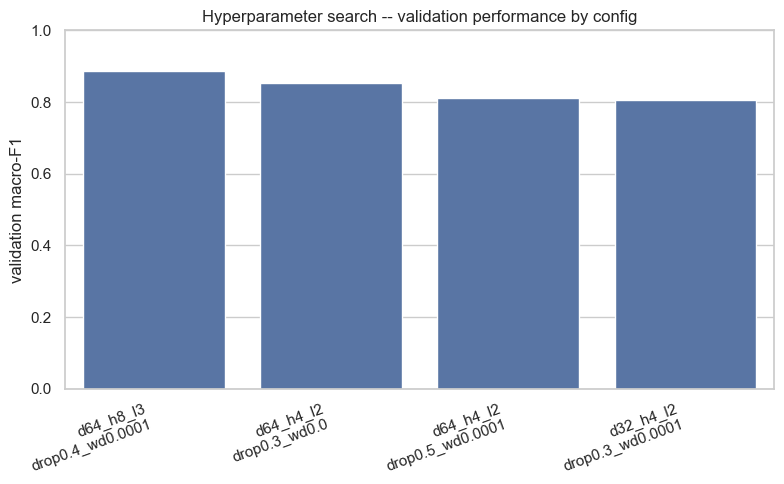


Best config: {'d_model': 64, 'nhead': 8, 'num_layers': 3, 'dim_feedforward': 128, 'dropout': 0.4, 'lr': 0.0005, 'weight_decay': 0.0001} (val f1_macro=0.887)


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = [f"d{p['d_model']}_h{p['nhead']}_l{p['num_layers']}\ndrop{p['dropout']}_wd{p['weight_decay']}"
          for p in search_df.to_dict("records")]
sns.barplot(x=labels, y=search_df["val_f1_macro"], ax=ax, color=sns.color_palette("deep")[0])
ax.set_ylim(0, 1)
ax.set_ylabel("validation macro-F1")
ax.set_xlabel("")
ax.set_title("Hyperparameter search -- validation performance by config")
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "hyperparam_search.png"), dpi=150)
plt.show()

print(f"\nBest config: {best_run['params']} (val f1_macro={best_run['val_f1_macro']:.3f})")

## 3. Final evaluation on the held-out test set

The best config by validation macro-F1 is evaluated **once** on the untouched test split.

In [8]:
model = best_run["model"]
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_preds = _predict(model, test_loader)
y_test = test_ds.y.numpy()

test_acc = accuracy_score(y_test, test_preds)
test_f1_macro = f1_score(y_test, test_preds, average="macro")
test_f1_weighted = f1_score(y_test, test_preds, average="weighted")
print(f"Test accuracy:    {test_acc:.3f}")
print(f"Test macro-F1:    {test_f1_macro:.3f}")
print(f"Test weighted-F1: {test_f1_weighted:.3f}")
print()
print(classification_report(y_test, test_preds, target_names=[str(c) for c in range(N_CLASSES)]))

Test accuracy:    0.890
Test macro-F1:    0.890
Test weighted-F1: 0.893

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.92      0.83      0.87        29
           2       0.89      1.00      0.94        25
           3       1.00      1.00      1.00        30
           4       1.00      1.00      1.00        41
           5       1.00      0.93      0.96        42
           6       0.80      0.62      0.70        32
           7       0.98      0.89      0.94        57
           8       0.84      0.82      0.83        45
           9       0.95      0.87      0.91        46
          10       0.95      0.95      0.95        37
          11       0.90      0.93      0.91        28
          12       0.54      0.83      0.66        30
          13       0.84      0.88      0.86        41
          14       0.87      0.83      0.85        41
          15       0.83      0.91      0.87        32

    acc

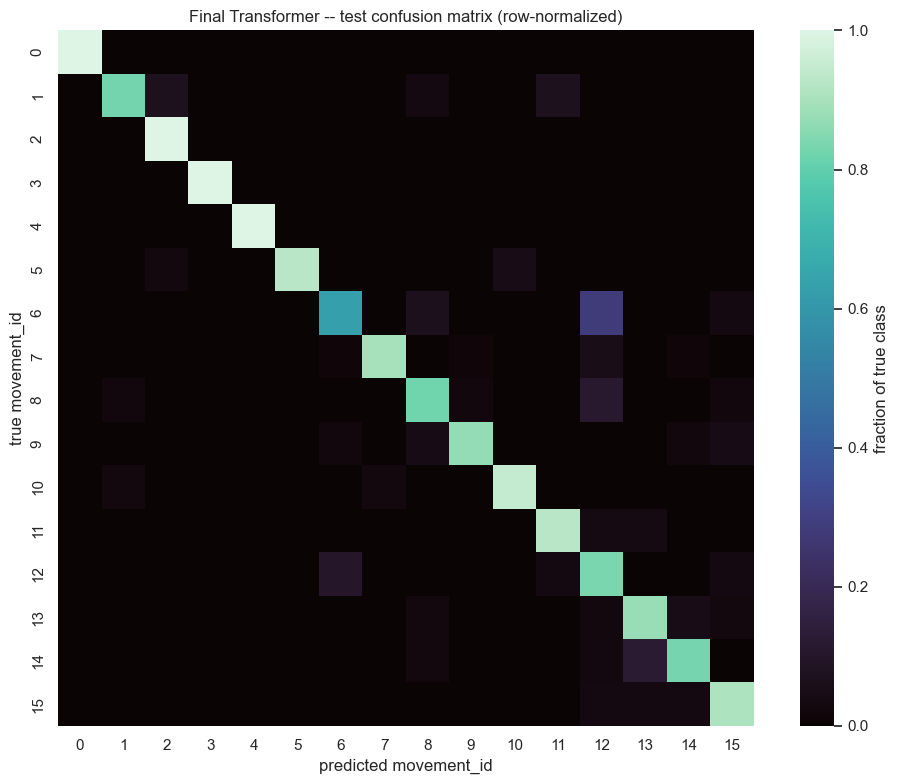

Weakest class: movement_id=12 (F1=0.66)


In [9]:
cm = confusion_matrix(y_test, test_preds, labels=np.arange(N_CLASSES), normalize="true")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, cmap="mako", xticklabels=range(N_CLASSES), yticklabels=range(N_CLASSES),
            square=True, cbar_kws={"label": "fraction of true class"}, ax=ax)
ax.set_xlabel("predicted movement_id")
ax.set_ylabel("true movement_id")
ax.set_title("Final Transformer -- test confusion matrix (row-normalized)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

per_class_f1 = f1_score(y_test, test_preds, average=None)
worst_class = int(np.argmin(per_class_f1))
print(f"Weakest class: movement_id={worst_class} (F1={per_class_f1[worst_class]:.2f})")

## 4. Save the final model

The winning hyperparameters get decided:

`d_model=64, nhead=8, num_layers=3, dim_feedforward=128, dropout=0.4` won on validation macro-F1.

In [10]:
best_hparams = {k: best_run["params"][k] for k in
                ("d_model", "nhead", "num_layers", "dim_feedforward", "dropout")}
print("Winning hyperparameters:", best_hparams)

model_path = os.path.join(THIS_DIR, "transformer_model.pt")
torch.save({
    "state_dict": model.state_dict(),
    "model_kwargs": best_hparams,
    "max_len": MAX_LEN,
    "stride": STRIDE,
    "n_classes": N_CLASSES,
    "test_accuracy": test_acc,
    "test_f1_macro": test_f1_macro,
}, model_path)
print(f"Saved trained model to {model_path}")

Winning hyperparameters: {'d_model': 64, 'nhead': 8, 'num_layers': 3, 'dim_feedforward': 128, 'dropout': 0.4}
Saved trained model to /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/Final_delivery/transformer_model.pt


## 5. Report

**Regularization:** dropout (0.3-0.5), Adam L2 weight decay (0 vs 1e-4), early stopping (patience 5), and class-weighted cross-entropy were applied across the whole grid -- the winning config uses dropout 0.4 and weight decay 1e-4.

**Hyperparameter adjustment:** the largest-capacity config (`d_model=64, nhead=8, num_layers=3`) won on validation macro-F1, ahead of the lighter configs -- more capacity plus stronger dropout/weight decay outperformed either smaller capacity or the same capacity with lighter regularization.

**Evaluate:** the reported test metrics come from a split the model never saw during training or hyperparameter selection, so they reflect genuine generalization rather than a re-fit against validation.

## References

- `Model_selection/model_selection.ipynb` -- architecture comparison that selected the Transformer.
- `Data/README.md` -- `manifest.csv` / `valid_length` semantics this notebook's `load_sequences` relies on.